In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
import pandas_ta
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline
import talib

from position_tools import calculate_trades, calculate_positions, count_since_last_signal

from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
import numpy as np
import sysconfig
f'gcc -shared -o positions.so -fPIC positions.c -I{sysconfig.get_path("include")} -I{np.get_include()}'

'gcc -shared -o positions.so -fPIC positions.c -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include'

In [3]:
import numpy as np
import pandas as pd
import talib
import position_tools  # Import the C extension module
import optuna

# Define helper functions for calculating metrics
def calculate_drawdown(pnl):
    running_max = pnl.cummax()
    drawdown = pnl - running_max
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_sharpe_ratio(rets):
    return rets.mean() / rets.std() if rets.std() > 0 else 0

def calculate_sortino_ratio(rets):
    downside_rets = rets[rets < 0]
    return rets.mean() / downside_rets.std() if downside_rets.std() > 0 else 0

def calculate_metrics(trades, trade_rets):
    if len(trades) == 0:
        return {metric: 0 for metric in [
            'tot_return', 'avg_return', 'avg_win', 'avg_loss',
            'win_ratio', 'profit_factor', 'n_trades', 'n_wins',
            'n_losses', 'max_drawdown', 'avg_drawdown', 'sharpe_ratio', 'sortino_ratio',
            'max_win', 'max_loss', 'sum_periods_in_wins', 'sum_periods_in_losses',
            'avg_periods_in_wins', 'avg_periods_in_losses', 'total_periods_in_trades',
            'avg_periods_in_trades', 'returns', 'cum_returns'
        ]}

    rets = trade_rets.reindex(trades[:, 1]).dropna()

    total_return = rets.sum()
    avg_return = rets.mean()

    wins = rets[rets > 0]
    losses = rets[rets <= 0]

    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = losses.mean() if len(losses) > 0 else 0
    max_win = wins.max() if len(wins) > 0 else 0
    max_loss = losses.min() if len(losses) > 0 else 0

    win_ratio = len(wins) / len(rets) if len(rets) > 0 else 0
    profit_factor = wins.sum() / abs(losses.sum()) if abs(losses.sum()) > 0 else np.nan
    n_trades = int(len(rets))
    n_wins = int(len(wins))
    n_losses = int(len(losses))

    # Calculate cumulative returns and drawdowns
    cum_rets = rets.cumsum()
    running_max = cum_rets.cummax()
    drawdowns = cum_rets - running_max
    max_drawdown = drawdowns.min()
    avg_drawdown = drawdowns.mean()

    # Calculate the number of periods for each trade
    periods_in_trades = trades[:, 1] - trades[:, 0] + 1  # periods in each trade

    # Calculate periods metrics
    win_indices = wins.index.values
    loss_indices = losses.index.values

    # Safely handle periods in trades by using valid indices
    win_period_indices = [i for i, end_idx in enumerate(trades[:, 1]) if end_idx in win_indices]
    loss_period_indices = [i for i, end_idx in enumerate(trades[:, 1]) if end_idx in loss_indices]

    sum_periods_in_wins = np.sum(periods_in_trades[win_period_indices]) if len(win_period_indices) > 0 else 0
    sum_periods_in_losses = np.sum(periods_in_trades[loss_period_indices]) if len(loss_period_indices) > 0 else 0
    avg_periods_in_wins = np.mean(periods_in_trades[win_period_indices]) if len(win_period_indices) > 0 else 0
    avg_periods_in_losses = np.mean(periods_in_trades[loss_period_indices]) if len(loss_period_indices) > 0 else 0
    total_periods_in_trades = np.sum(periods_in_trades)
    avg_periods_in_trades = np.mean(periods_in_trades)

    sharpe_ratio = calculate_sharpe_ratio(rets)
    sortino_ratio = calculate_sortino_ratio(rets)

    return {
        'tot_return': total_return,
        'avg_return': avg_return,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'win_ratio': win_ratio,
        'profit_factor': profit_factor,
        'n_trades': n_trades,
        'n_wins': n_wins,
        'n_losses': n_losses,
        'max_drawdown': max_drawdown,
        'avg_drawdown': avg_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_win': max_win,
        'max_loss': max_loss,
        'sum_periods_in_wins': sum_periods_in_wins,
        'sum_periods_in_losses': sum_periods_in_losses,
        'avg_periods_in_wins': avg_periods_in_wins,
        'avg_periods_in_losses': avg_periods_in_losses,
        'total_periods_in_trades': total_periods_in_trades,
        'avg_periods_in_trades': avg_periods_in_trades,
        'returns': rets,
        'cum_returns': cum_rets,
    }

def print_metrics_table(metrics, convert_to_pct=False):
    headers = ["Metric", "Overall", "Long Positions", "Short Positions"]
    metrics_list = [
        'tot_return', 'max_drawdown', 'n_trades', 'sharpe_ratio', 'sortino_ratio', 
        'avg_return', 'max_win', 'max_loss', 'avg_win', 'avg_loss',
        'win_ratio', 'profit_factor', 'n_wins',
        'n_losses', 'avg_drawdown',
        'sum_periods_in_wins', 'sum_periods_in_losses', 'avg_periods_in_wins', 'avg_periods_in_losses',
        'total_periods_in_trades', 'avg_periods_in_trades'
    ]
    
    # Helper function to convert log returns and drawdowns to percentages
    def convert_log_to_pct(value):
        return (np.exp(value) - 1) * 100 if convert_to_pct else value

    # Metrics that should be converted to percentage if `convert_to_pct` is True
    conversion_metrics = {
        'tot_return', 'avg_return', 'max_win', 'max_loss', 'avg_win', 'avg_loss', 
        'max_drawdown', 'avg_drawdown'
    }

    # Print headers
    print(f"{headers[0]:<25} | {headers[1]:>15} | {headers[2]:>15} | {headers[3]:>15}")
    print("-" * 80)
    
    # Print each row dynamically
    for metric in metrics_list:
        if metric in conversion_metrics:
            overall_value = convert_log_to_pct(metrics['overall_metrics'].get(metric, 0))
            long_value = convert_log_to_pct(metrics['long_metrics'].get(metric, 0))
            short_value = convert_log_to_pct(metrics['short_metrics'].get(metric, 0))
        else:
            overall_value = metrics['overall_metrics'].get(metric, 0)
            long_value = metrics['long_metrics'].get(metric, 0)
            short_value = metrics['short_metrics'].get(metric, 0)

        print(f"{metric.replace('_', ' ').title():<25} | {overall_value:>15.4f} | {long_value:>15.4f} | {short_value:>15.4f}")

def backtest(data, nhours, params, short_long=[1, -1], xmult=1, transaction_cost=0.001, slippage=0.003, precision=3, period_costs=None):
    lclose = data['close'].apply(np.log)

    # Calculate indicators
    # data['rsi'] = talib.RSI(data['close'], timeperiod=params['rsi_period'])
    data['donch_up'] = data['close'].rolling(window=params['up_lookback']).max().shift(params['up_lag'])
    data['donch_dn'] = data['close'].rolling(window=params['dn_lookback']).min().shift(params['dn_lag'])
    data['donch_mid'] = (1 - params['band_offset']) * data['donch_up'] + params['band_offset'] * data['donch_dn']

    # Signal generation
    bull = (
        (data['close'] > data['donch_up']) 
        & (~data['donch_up'].isna())
    ).astype(int)

    bull_end = (
        (data['close'] < data['donch_mid']) 
        & (~data['donch_mid'].isna())
    ).astype(int)

    bear = (
        (data['close'] < data['donch_dn']) 
        & (~data['donch_dn'].isna())
    ).astype(int)

    bear_end = (
        (data['close'] > data['donch_mid']) 
        & (~data['donch_mid'].isna())
    ).astype(int)

    # Use the position_tools C extension for trade calculation
    itrades = position_tools.calculate_trades(
        bull.values,
        bull_end.values,
        bear.values,
        bear_end.values
    )

    if len(itrades) == 0 or not itrades.any():
        print('No trades found.')
        return {}

    # Calculate trade returns using log prices
    trade_rets = pd.Series(
        itrades[:, 2] * (lclose.iloc[itrades[:, 1]].values - lclose.iloc[itrades[:, 0]].values),
        index=itrades[:, 1]
    )
    trade_rets *= xmult
    trade_rets -= np.log1p(transaction_cost + slippage)

    # Apply period costs if provided
    if period_costs is not None:
        if isinstance(period_costs, (int, float)):
            # If period costs is a single number, apply it uniformly
            trade_rets -= period_costs * (itrades[:, 1] - itrades[:, 0] + 1)
        elif isinstance(period_costs, (np.ndarray, pd.Series)):
            # If period costs is an array, apply the corresponding costs
            cost_array = pd.Series(period_costs, index=data.index)
            trade_rets -= cost_array.reindex(itrades[:, 1]).fillna(0) * (itrades[:, 1] - itrades[:, 0] + 1)
        else:
            raise ValueError("period_costs should be either a single number or an array-like structure.")

    # Use the C extension to calculate positions
    strat_pnl = pd.Series(position_tools.calculate_positions(itrades, lclose.values, precision, slippage, transaction_cost), index=data.index)

    # Calculate metrics
    long_metrics = calculate_metrics(itrades[itrades[:, 2] == 1], trade_rets)
    short_metrics = calculate_metrics(itrades[itrades[:, 2] == -1], trade_rets)
    overall_metrics = calculate_metrics(itrades, trade_rets)

    return {
        'long_metrics': long_metrics,
        'short_metrics': short_metrics,
        'overall_metrics': overall_metrics,
        'itrades': itrades,
        'strat_pnl_pct': strat_pnl,  # Calculated by the C extension
        'entry_points': data.index[itrades[:, 0]],
        'exit_points': data.index[itrades[:, 1]],
        'long_returns': long_metrics['returns'],
        'short_returns': short_metrics['returns'],
        'overall_returns': overall_metrics['returns'],
        'long_cum_returns': long_metrics['cum_returns'],
        'short_cum_returns': short_metrics['cum_returns'],
        'overall_cum_returns': overall_metrics['cum_returns'],
    }


def suggest_params(trial, param_defs):
    params = {}
    for param_name, param_config in param_defs.items():
        method_name = param_config.get('method', 'suggest_int')  # Default to 'suggest_int' if not specified
        method = getattr(trial, method_name)
        params[param_name] = method(param_name, param_config['min'], param_config['max'])
    return params

import optuna
import numpy as np

def get_nested_metric(metrics, path):
    """
    Efficiently fetches the value from a nested dictionary using a dot-separated string path.
    
    Args:
    - metrics (dict): The dictionary to traverse.
    - path (str): The dot-separated string path (e.g., "overall_metrics.sharpe_ratio").
    
    Returns:
    - The value at the end of the path, or None if the path is invalid.
    """
    keys = path.split('.')
    value = metrics
    
    for key in keys:
        if isinstance(value, dict) and key in value:
            value = value[key]
        else:
            return None
    return value

def optimize(data, nhours, param_defs, backtest_fn=backtest, short_long=None, xmult=1, n_trials=100, 
             optimize_metrics=None, directions=None):
    
    # Define default directions for each metric
    default_directions = {
        'sharpe_ratio': 'maximize',
        'sortino_ratio': 'maximize',
        'max_drawdown': 'minimize',
        'tot_return': 'maximize',
        'avg_drawdown': 'minimize',
        'avg_win': 'maximize',
        'avg_loss': 'minimize',
        'win_ratio': 'maximize',
        'profit_factor': 'maximize',
        'n_trades': 'maximize',  # Depending on the context, some may want to minimize this
        'max_win': 'maximize',
        'max_loss': 'minimize',
    }
    
    # Set default metrics if none provided
    if optimize_metrics is None:
        optimize_metrics = ['sharpe_ratio']  # Default metric
    
    # Apply default directions if none are provided
    if directions is None:
        directions = [default_directions.get(metric.split('.')[-1], 'maximize') for metric in optimize_metrics]
    
    # Check for mismatched lengths
    if len(optimize_metrics) != len(directions):
        raise ValueError("The number of optimize metrics must match the number of directions.")
    
    def objective(trial):
        params = suggest_params(trial, param_defs)
        metrics = backtest_fn(data, nhours, params, short_long=short_long, xmult=xmult)
        
        if not metrics:
            return [float('-inf') if d == 'maximize' else float('inf') for d in directions]
        
        results = []
        for metric, direction in zip(optimize_metrics, directions):
            value = None

            # Check if metric is a function
            if callable(metric):
                value = metric(metrics)
            else:
                value = get_nested_metric(metrics, metric)

            # Apply default value if metric not found
            if value is None or np.isnan(value):
                value = float('-inf') if direction == 'maximize' else float('inf')

            results.append(value)
        
        return results

    # Set up the study with the correct directions for multiple objectives
    study = optuna.create_study(directions=directions)
    study.optimize(objective, n_trials=n_trials)
    return study



In [4]:
param_defs = {
    # 'rsi_period': {'method': 'suggest_int', 'min': 5, 'max': 30},
    # 'up_rsi_thre': {'method': 'suggest_int', 'min': 50, 'max': 70},
    'up_lookback': {'method': 'suggest_int', 'min': 10, 'max': 100},
    'dn_lookback': {'method': 'suggest_int', 'min': 10, 'max': 100},
    'up_lag': {'method': 'suggest_int', 'min': 5, 'max': 20},
    'dn_lag': {'method': 'suggest_int', 'min': 5, 'max': 20},
    'band_offset': {'method': 'suggest_float', 'min': 0.0, 'max': 1.0},
    # 'count_since_last_cross': {'method': 'suggest_int', 'min': 1, 'max': 10},
}


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def print_performance(data, nhours, asset, reset_index=False, title='', params=None, btkwargs=None):
    if reset_index:
        data = data.copy().reset_index(drop=True)
    metrics = backtest(data, nhours, params, **btkwargs)
    
    print_metrics_table(metrics, convert_to_pct=True)
    itrades = metrics['itrades']

    if itrades is None or len(itrades) == 0:
        print("No trades found.")
        return None, metrics
    
    # Extract the trade exit points' indices
    trade_exit_indices = itrades[:, 1]
    
    # Separate the indices for long and short trades
    long_trade_indices = trade_exit_indices[itrades[:, 2] == 1]
    short_trade_indices = trade_exit_indices[itrades[:, 2] == -1]

    # Calculate cumulative returns for overall, long, and short positions
    overall_cum_returns = metrics['overall_cum_returns']
    long_cum_returns = metrics['long_cum_returns']
    short_cum_returns = metrics['short_cum_returns']

    # Align the cumulative returns with the trade exit indices
    combined_pnl_pct = pd.Series(np.exp(overall_cum_returns)).subtract(0).set_axis(data.index[trade_exit_indices])

    if len(long_trade_indices) > 0:
        long_pnl_pct = pd.Series(np.exp(long_cum_returns)).subtract(0).set_axis(data.index[long_trade_indices])
    else:
        short_pnl_pct = pd.Series([0] * len(data)).subtract(0).set_axis(data.index)

    if len(short_trade_indices) > 0:
        short_pnl_pct = pd.Series(np.exp(short_cum_returns)).subtract(0).set_axis(data.index[short_trade_indices])
    else:
        short_pnl_pct = pd.Series([0] * len(data)).subtract(0).set_axis(data.index)

    # Plot the results with the best parameters
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True, height_ratios=[2, 1])
    plt.title(f'Donchian Breakout {title} / {asset} / {nhours} / {params}')

    # Plot the price and Donchian channels
    ax1.plot(data.index, data['close'], label='Close Price', lw=0.5)
    ax1.plot(data.index, data['donch_up'], label='Donchian Up', color='blue', lw=0.5)
    ax1.plot(data.index, data['donch_dn'], label='Donchian Down', color='red', lw=0.5)
    ax1.plot(data.index, data['donch_mid'], label='Donchian Mid', color='black', lw=0.5, linestyle='-')
    ax1.legend(loc='best')

    # Plot PnL as percentage for long, short, and combined
    ax2.axhline(0, color='black', lw=1)  # Baseline for percentage returns
    ax2.plot(combined_pnl_pct.index, combined_pnl_pct, label='Combined PNL %', color='teal', alpha=0.8, lw=2)
    if len(long_trade_indices) > 0:
        ax2.plot(long_pnl_pct.index, long_pnl_pct, label='Long PNL %', color='green', alpha=0.8, lw=2)
    if len(short_trade_indices) > 0:
        ax2.plot(short_pnl_pct.index, short_pnl_pct, label='Short PNL %', color='red', alpha=0.8, lw=2)
    
    ax2.set_yscale('log', base=2)
    ax2.legend(loc='best')

    # Plot entry and exit points
    for x in metrics['entry_points'].values: 
        ax1.axvline(x, color='blue', lw=1, alpha=0.2)
        ax2.axvline(x, color='blue', lw=1, alpha=0.2)
    for xx in metrics['exit_points'].values:
        ax1.axvline(xx, color='red', lw=1, alpha=0.2)
        ax2.axvline(xx, color='red', lw=1, alpha=0.2)
    for i in range(len(itrades)):
        ax1.axvspan(xmin=data.index[itrades[i, 0]], xmax=data.index[itrades[i, 1]], color=['red', 'green'][(itrades[i, 2] + 1) // 2], alpha=0.1)
        ax2.axvspan(xmin=data.index[itrades[i, 0]], xmax=data.index[itrades[i, 1]], color=['red', 'green'][(itrades[i, 2] + 1) // 2], alpha=0.1)
    
    ax1.grid(axis='y')
    ax2.grid(axis='y')
    plt.show()
    return fig, metrics


aparams = [{'up_lookback': 91, 'dn_lookback': 89, 'up_lag': 18, 'dn_lag': 20, 'band_offset': 0.4144990339143617}, {'up_lookback': 85, 'dn_lookback': 99, 'up_lag': 19, 'dn_lag': 18, 'band_offset': 0.4144990339143617}, {'up_lookback': 41, 'dn_lookback': 77, 'up_lag': 15, 'dn_lag': 15, 'band_offset': 0.1463900755229075}, {'up_lookback': 91, 'dn_lookback': 88, 'up_lag': 20, 'dn_lag': 20, 'band_offset': 0.15061342287746382}]
params = {'up_lookback': 91, 'dn_lookback': 89, 'up_lag': 18, 'dn_lag': 20, 'band_offset': 0.4144990339143617}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        438.0776 |        232.6716 |         61.7444
Max Drawdown              |        -38.5113 |        -42.1229 |        -45.1836
N Trades                  |         84.0000 |         52.0000 |         32.0000


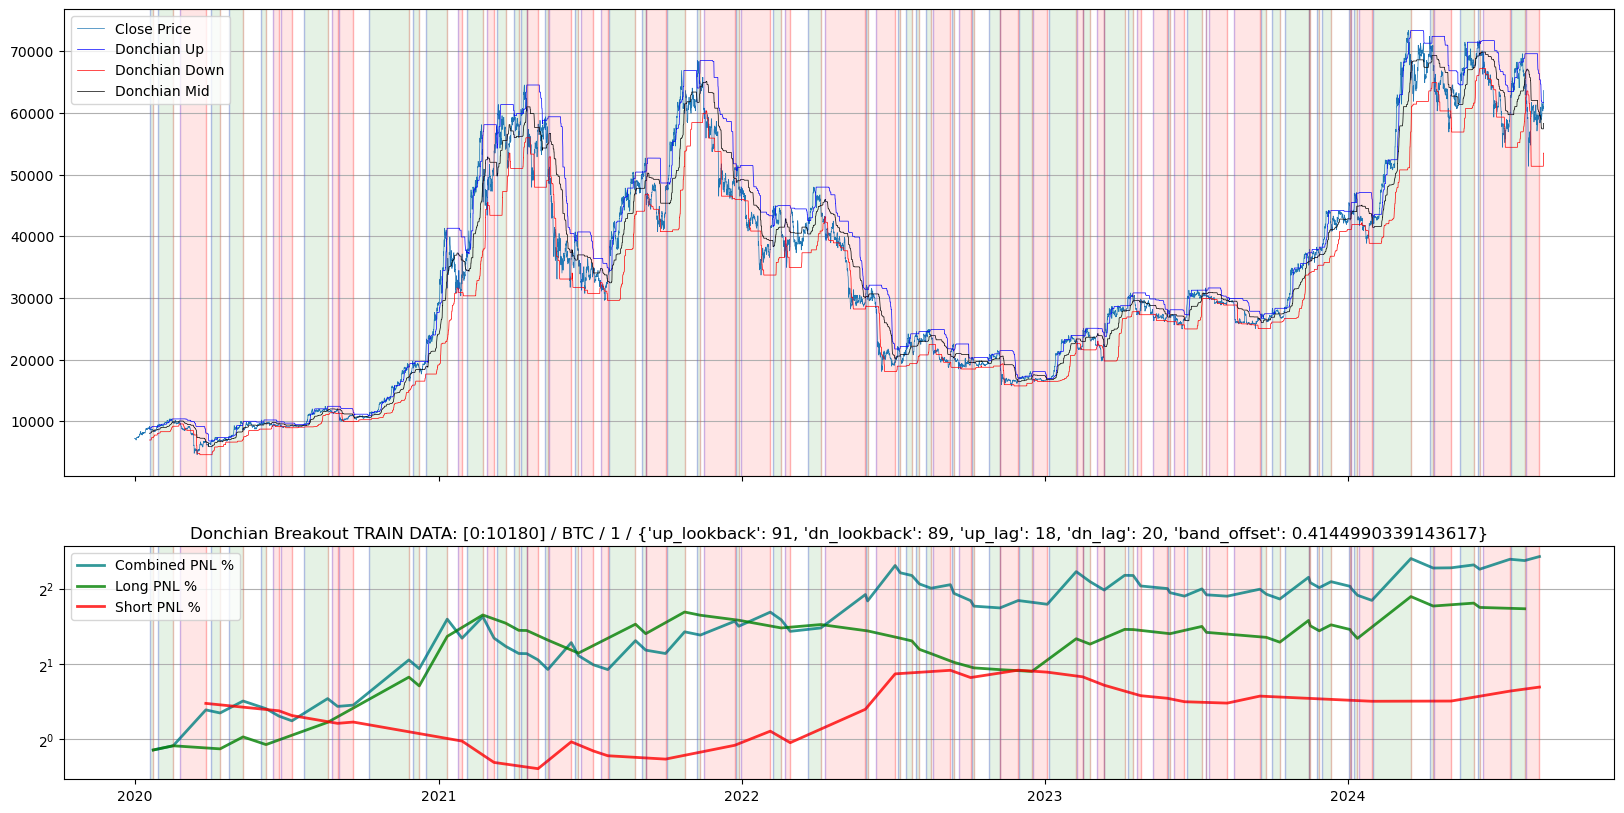

params = {'up_lookback': 85, 'dn_lookback': 99, 'up_lag': 19, 'dn_lag': 18, 'band_offset': 0.4144990339143617}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        599.1429 |        306.1234 |         72.1504
Max Drawdown              |        -40.1948 |        -40.8549 |        -42.2950
N Trades                  |         82.0000 |         51.0000 |         31.0000
Sharpe Ratio              |          0.1734 |          0.1964 |          0.1313
Sortino Ratio             |          0.6305 |          1.1351 |          0.3246
Avg Return                |          2.3999 |          2.7861 |          1.7677
Max Win                   |         57.7760 |         57.7760 |         39.4451
Max Loss                  |        -17.8571 |         -8.7617 |        -17.8571
Avg Win                 

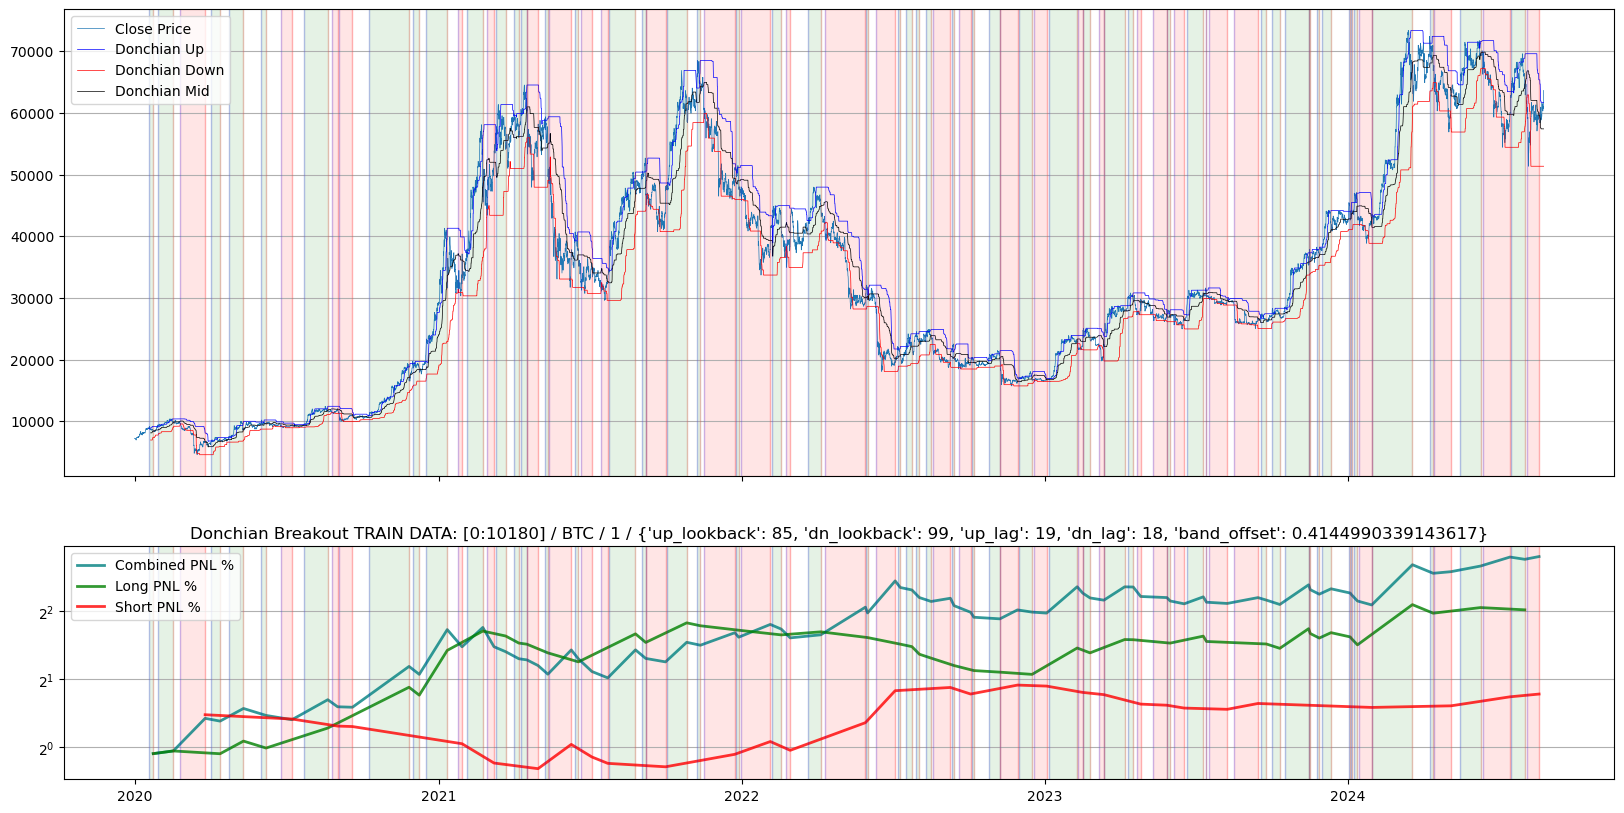

params = {'up_lookback': 41, 'dn_lookback': 77, 'up_lag': 15, 'dn_lag': 15, 'band_offset': 0.1463900755229075}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        296.7817 |        205.8197 |         29.7437
Max Drawdown              |        -30.4184 |        -29.8555 |        -39.5087
N Trades                  |        157.0000 |        114.0000 |         43.0000
Sharpe Ratio              |          0.1021 |          0.1226 |          0.0598
Sortino Ratio             |          0.3105 |          0.5062 |          0.1421
Avg Return                |          0.8817 |          0.9854 |          0.6074
Max Win                   |         39.8793 |         39.8793 |         33.8973
Max Loss                  |        -15.9437 |         -8.0694 |        -15.9437
Avg Win                 

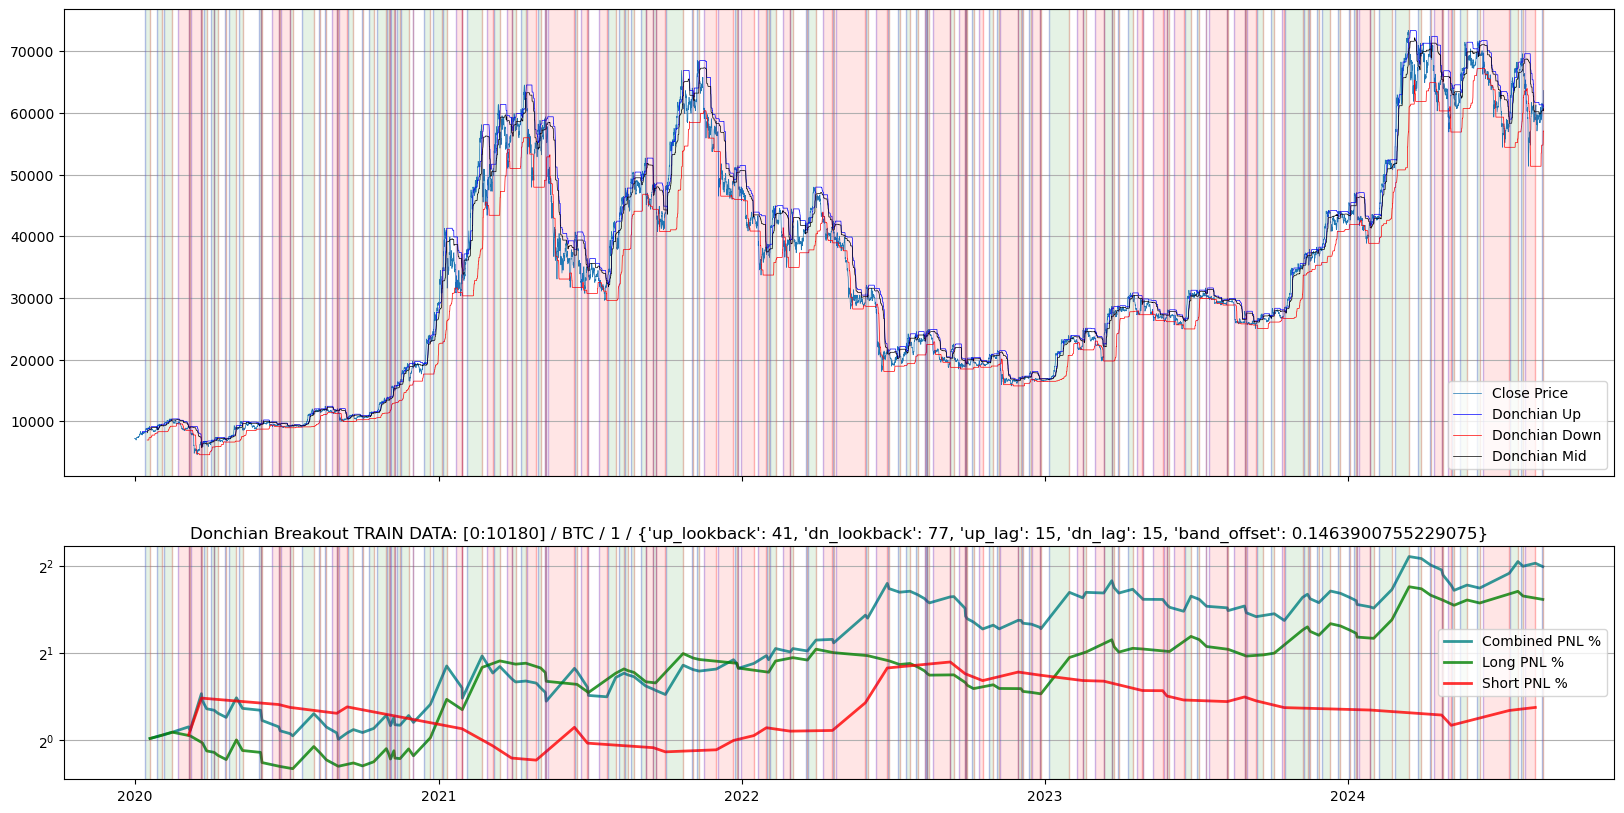

params = {'up_lookback': 91, 'dn_lookback': 88, 'up_lag': 20, 'dn_lag': 20, 'band_offset': 0.15061342287746382}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        372.0897 |        278.4354 |         24.7477
Max Drawdown              |        -34.8553 |        -34.9513 |        -41.4573
N Trades                  |        101.0000 |         74.0000 |         27.0000
Sharpe Ratio              |          0.1414 |          0.1884 |          0.0583
Sortino Ratio             |          0.3597 |          0.9138 |          0.1184
Avg Return                |          1.5485 |          1.8148 |          0.8223
Max Win                   |         44.8550 |         42.6257 |         44.8550
Max Loss                  |        -23.6607 |         -8.3690 |        -23.6607
Avg Win                

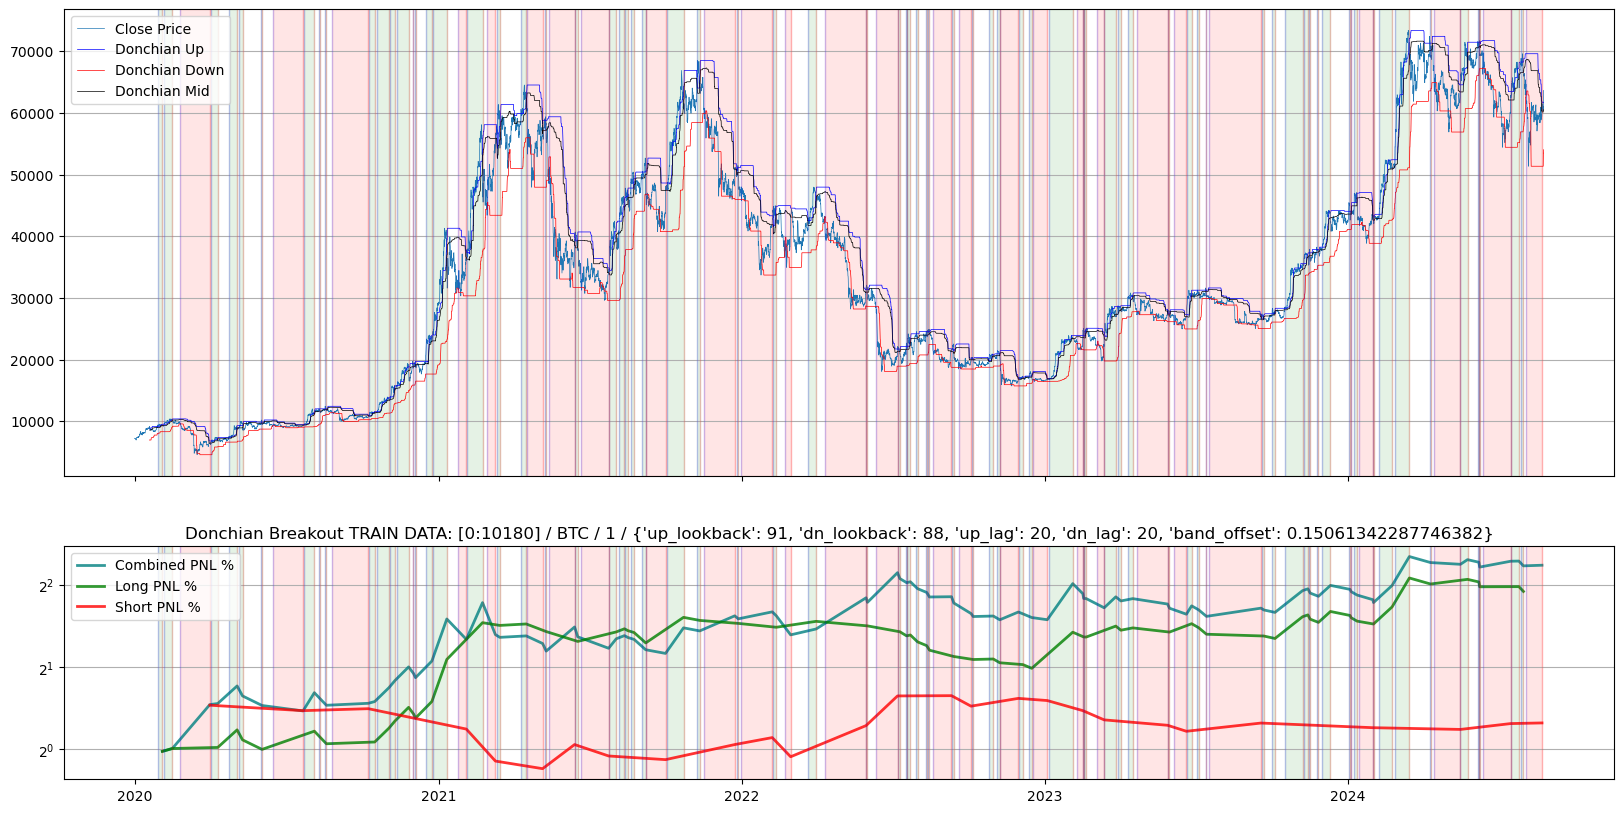

In [7]:

# Proceed with optimizing and testing as before

optuna.logging.set_verbosity(optuna.logging.ERROR)
# Load the data
# asset = 'GOOGL'
# data = load_sp500_stock_candles(asset)['2010':'2025']
# data['close'] = data['adj close']
# data = load_russel2000_candles('XOXO')['2006':]
asset, quote, timeframe, exchange = 'BTC', 'USDT', '4h', 'binance'
data = load_candles('binance',asset, quote, timeframe)['2020':'2025']#.iloc[-35000:-5000]
nhours = 1; train_ratio = 1
# data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
data_train = data.iloc[:int(data.shape[0]*train_ratio)]; data_test = data.iloc[data_train.shape[0]:]
study = optimize(data_train, nhours, param_defs,backtest_fn=backtest, short_long=[-1,1],xmult=1,n_trials=200)
# def custom_metric(metrics):
#     return metrics['overall_metrics']['tot_return'] / abs(metrics['overall_metrics']['max_drawdown'])

study = optimize(
    data, 
    nhours, 
    param_defs, 
    optimize_metrics=['overall_metrics.max_drawdown', 'short_metrics.profit_factor'],
    directions=['maximize', 'maximize'],
    n_trials=100
)
aparams = [t.params for t in reversed(study.best_trials[-10:])]

print(f'aparams = {aparams}')
for params in aparams:
    print('================================================================')
    print(f'params = {params}')
    if len(data_train): 
        print('--- TRAIN -----------------------------------------------------')
        fig_tr,res_tr = print_performance(data_train,nhours,asset,reset_index=False,params=params,btkwargs={'short_long':[1,-1], 'xmult':1, 'slippage': 0.005, 'transaction_cost': 0.001, 'period_costs': 0.0003/6}, title=f'TRAIN DATA: [0:{data_train.shape[0]}]')
    # if len(data_test): 
        # print('--- TEST ------------------------------------------------------')
        # fig_ts, res_ts = print_performance(data_test,nhours,asset,reset_index=False,params=params,btkwargs={'short_long':[-1,1], 'xmult':1}, title=f'TEST DATA: [{data_test.shape[0]}:{data.shape[0]}]')
    


In [ ]:
'['+"98	149	53	106	0.28".replace("\t",',')+']'


In [ ]:
real = talib.NATR(data.high, data.low, data.close, timeperiod=14)
real.hist()

## Parameer analysis

In [ ]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.duration.total_seconds(), target_name="duration"
)

In [ ]:
optuna.visualization.plot_pareto_front(study, target_names=["tot_return", "trade_max_drawdown"])

In [ ]:
plot_edf(study,target=lambda s: s.values[0])

In [ ]:
fig = plot_rank(study,target=lambda s: s.values[0])
plt.tight_layout()
fig


In [ ]:
plot_timeline(study)

In [ ]:
fig = plot_intermediate_values(study)

# fig.update_layout(
#     title="Hyperparameter optimization for Donchian Breakout strategy",
#     xaxis_title="Epoch",
#     yaxis_title="tot_return",
# )
fig

In [ ]:
for params in [t.params for t in study.best_trials]:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

## Backtest a list of params on a bunch of assets

#### Load and map assets to existing data from exchanges

In [260]:
import os
base_data_dir = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data"
# quote, timeframe, nhours = 'USDT', '8h', 8
exchanges = ['binance', 'kucoin', 'bybit', 'bitget']
with open("assets-portfolio.txt", "r") as file: assets = [line.strip() for line in file.readlines()][:20]
# assets = filter(lambda a: not 'USD' in a, assets)
assets = [a for a in assets if 'USD' not in a and a not in ['LUNA', 'RENDER']]
# assets
# df_pf = pd.DataFrame(assets,columns=['asset'])
dfae = pd.DataFrame([
    [(os.path.exists(f'{base_data_dir}/{exchange}/{asset}_{quote}-{timeframe}.json')) for exchange in exchanges]
    for asset in assets
]).set_axis(exchanges, axis=1)#.set_axis(assets,axis=0)
dfae.index = assets

dfae['first_exch'] = dfae.apply(lambda row: row.idxmax() if row.any() else None, axis=1)
# assets, exchanges = 
assets, exchanges = (dfae[~dfae['first_exch'].isna()][['first_exch']].reset_index().T.values)
asset_exchange = list(dfae[~dfae['first_exch'].isna()][['first_exch']].to_records())
# asset_exchange
# list(asset_exch)



#### Backtest and collect results

In [261]:
def xtract_primitive_values(opt_bt) : 
    return {k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))}

def remove_keys_with_unwanted_values(d):
    """
    Recursively remove keys from a dictionary if their values are
    instances of list, numpy array, pandas Series, or pandas DataFrame.
    """
    if not isinstance(d, dict):
        return d

    keys_to_remove = [key for key, value in d.items() if isinstance(value, (list, np.ndarray, pd.Series, pd.DataFrame, pd.DatetimeIndex))]

    for key in keys_to_remove:
        del d[key]

    # Recursively apply the function to sub-dictionaries
    for key, value in d.items():
        if isinstance(value, dict):
            remove_keys_with_unwanted_values(value)
    
    return d

In [281]:
# quote, timeframe, nhours = 'USDT', '4h', 4
# inc_metrics = ['asset', 'ipa', 'long_metrics', 'short_metrics', 'overall_metrics', 'rsi_period', 'up_rsi_thre', 'up_lookback', 'dn_lookback', 'up_lag', 'dn_lag', 'band_offset', 'count_since_last_cross']
bt_resa = []
for asset,exchange in tqdm(asset_exchange):
    data = load_candles(exchange,asset,quote,timeframe)['2020-12':]
    for ipa,params in enumerate(aparams):
        res = backtest(data,nhours, params)
        bt_resa.append({'asset.asset': asset, 'tfr.tfr': timeframe, 'ipa.ipa': ipa, **remove_keys_with_unwanted_values(res), 'params': params})
                

100%|██████████| 20/20 [00:00<00:00, 22.58it/s]


In [282]:
# bt_resa[0:1]

In [283]:
from collections.abc import MutableMapping

    
def flatten_dict(d, parent_key='', sep='.'):
    items = []
    for k, v in d.items():
        new_key = f'{parent_key}{sep}{k}' if parent_key else k
        if isinstance(v, MutableMapping):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


flattened_data = [flatten_dict(item) for item in bt_resa]

df = pd.DataFrame(flattened_data)
df.columns = pd.MultiIndex.from_tuples([tuple(col.split('.')) for col in df.columns], names=['Category', 'Type'])

# df.index.set_names(['Category', 'Type'], inplace=True)

df = df.loc[:,[('asset', 'asset'),
 ('tfr', 'tfr'),
 ('ipa', 'ipa'),
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('overall_metrics', 'sharpe_ratio'),
 ('overall_metrics', 'sortino_ratio'),
 ('overall_metrics', 'n_trades'),
 ('overall_metrics', 'win_ratio'),
 ('long_metrics', 'tot_return'),
 ('long_metrics', 'max_drawdown'),
 ('short_metrics', 'tot_return'),
 ('short_metrics', 'max_drawdown'),
 ('params', 'up_lookback'),
 ('params', 'dn_lookback'),
 ('params', 'up_lag'),
 ('params', 'dn_lag'),
 ('params', 'band_offset')]]

df.loc[:,[
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('long_metrics', 'tot_return'),
 ('long_metrics', 'max_drawdown'),
 ('short_metrics', 'tot_return'),
 ('short_metrics', 'max_drawdown')]] = df.loc[:,[
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('long_metrics', 'tot_return'),
 ('long_metrics', 'max_drawdown'),
 ('short_metrics', 'tot_return'),
 ('short_metrics', 'max_drawdown')]].apply(np.expm1).round(2)
 
df.to_csv(f'asset_donch_backtest--{timeframe}.csv', index=False)
# df.columns
# df = df[(df[('overall_metrics', 'sortino_ratio')] > 0.6) & (df[('overall_metrics', 'tot_return')] > 3)]
df = df[(df[('overall_metrics', 'max_drawdown')] > -0.6) & (df[('overall_metrics', 'tot_return')] > 5)]
print(f'aparams={aparams}')
df = df[[('asset', 'asset'),
 ('tfr', 'tfr'),
 ('ipa', 'ipa'),
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('overall_metrics', 'sharpe_ratio'),
 ('overall_metrics', 'sortino_ratio'),
 ('overall_metrics', 'n_trades'),
 ('overall_metrics', 'win_ratio'),
 ('params', 'up_lookback'),
 ('params', 'dn_lookback'),
 ('params', 'up_lag'),
 ('params', 'dn_lag'),
 ('params', 'band_offset')]].droplevel(0, axis=1)
# df
# df.sort_values(('tot_return'))#.head(50)
df = df.loc[df.groupby(['asset'])['tot_return'].idxmax()]
# df.groupby('asset', axis=1).apply(
#     lambda x: x.loc[x[ ('tot_return')].idxmax()])
print(f'length: {df.shape[0]}')
df

aparams=[{'up_lookback': 35, 'dn_lookback': 47, 'up_lag': 9, 'dn_lag': 16, 'band_offset': 0.8678943121977075}, {'up_lookback': 94, 'dn_lookback': 71, 'up_lag': 10, 'dn_lag': 16, 'band_offset': 0.9931077566463022}, {'up_lookback': 63, 'dn_lookback': 89, 'up_lag': 10, 'dn_lag': 12, 'band_offset': 0.32688093959175124}, {'up_lookback': 96, 'dn_lookback': 58, 'up_lag': 8, 'dn_lag': 13, 'band_offset': 0.5635254070246954}, {'up_lookback': 55, 'dn_lookback': 62, 'up_lag': 15, 'dn_lag': 20, 'band_offset': 0.7483341505748494}, {'up_lookback': 63, 'dn_lookback': 89, 'up_lag': 10, 'dn_lag': 12, 'band_offset': 0.32688093959175124}, {'up_lookback': 94, 'dn_lookback': 71, 'up_lag': 14, 'dn_lag': 11, 'band_offset': 0.259854022220006}, {'up_lookback': 26, 'dn_lookback': 70, 'up_lag': 8, 'dn_lag': 16, 'band_offset': 0.797482516584806}, {'up_lookback': 41, 'dn_lookback': 49, 'up_lag': 5, 'dn_lag': 19, 'band_offset': 0.9437094323653118}]
length: 13


Type,asset,tfr,ipa,tot_return,max_drawdown,sharpe_ratio,sortino_ratio,n_trades,win_ratio,up_lookback,dn_lookback,up_lag,dn_lag,band_offset
0,ADA,4h,0,10.41,-0.58,0.099792,0.399927,150,0.366667,35,47,9,16,0.867894
40,APT,4h,4,6.01,-0.51,0.162447,0.985265,50,0.340000,55,62,15,20,0.748334
67,AVAX,4h,4,626.47,-0.43,0.246444,1.203342,97,0.494845,55,62,15,20,0.748334
73,AXS,4h,1,12.60,-0.59,0.067399,0.204160,156,0.275641,94,71,10,16,0.993108
89,BEAM,4h,8,5.03,-0.47,0.259649,1.189714,23,0.565217,41,49,5,19,0.943709
99,CHZ,4h,0,42.09,-0.58,0.085474,0.468453,153,0.366013,35,47,9,16,0.867894
123,DOGE,4h,6,23.54,-0.57,0.157040,0.591950,78,0.410256,94,71,14,11,0.259854
127,DOT,4h,1,8.49,-0.51,0.090830,0.284738,143,0.342657,94,71,10,16,0.993108
141,EGLD,4h,6,46.12,-0.57,0.198980,0.944535,78,0.358974,94,71,14,11,0.259854
145,ENJ,4h,1,67.24,-0.37,0.117389,0.586237,145,0.337931,94,71,10,16,0.993108


Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |      26197.6849 |       2376.4960 |        961.8909
Max Drawdown              |        -61.2904 |        -66.1244 |        -59.0177
N Trades                  |        252.0000 |         84.0000 |        168.0000
Sharpe Ratio              |          0.1417 |          0.1626 |          0.1486
Sortino Ratio             |          0.5570 |          0.8657 |          0.5519
Avg Return                |          2.2358 |          3.8947 |          1.4163
Max Win                   |        190.9980 |        190.9980 |         81.0848
Max Loss                  |        -18.0337 |        -18.0337 |        -14.0519
Avg Win                   |         15.3952 |         29.1368 |          9.6421
Avg Loss                  |         -5.1051 |         -7.9302 |         -3.5745
Win Ratio                 |          0.

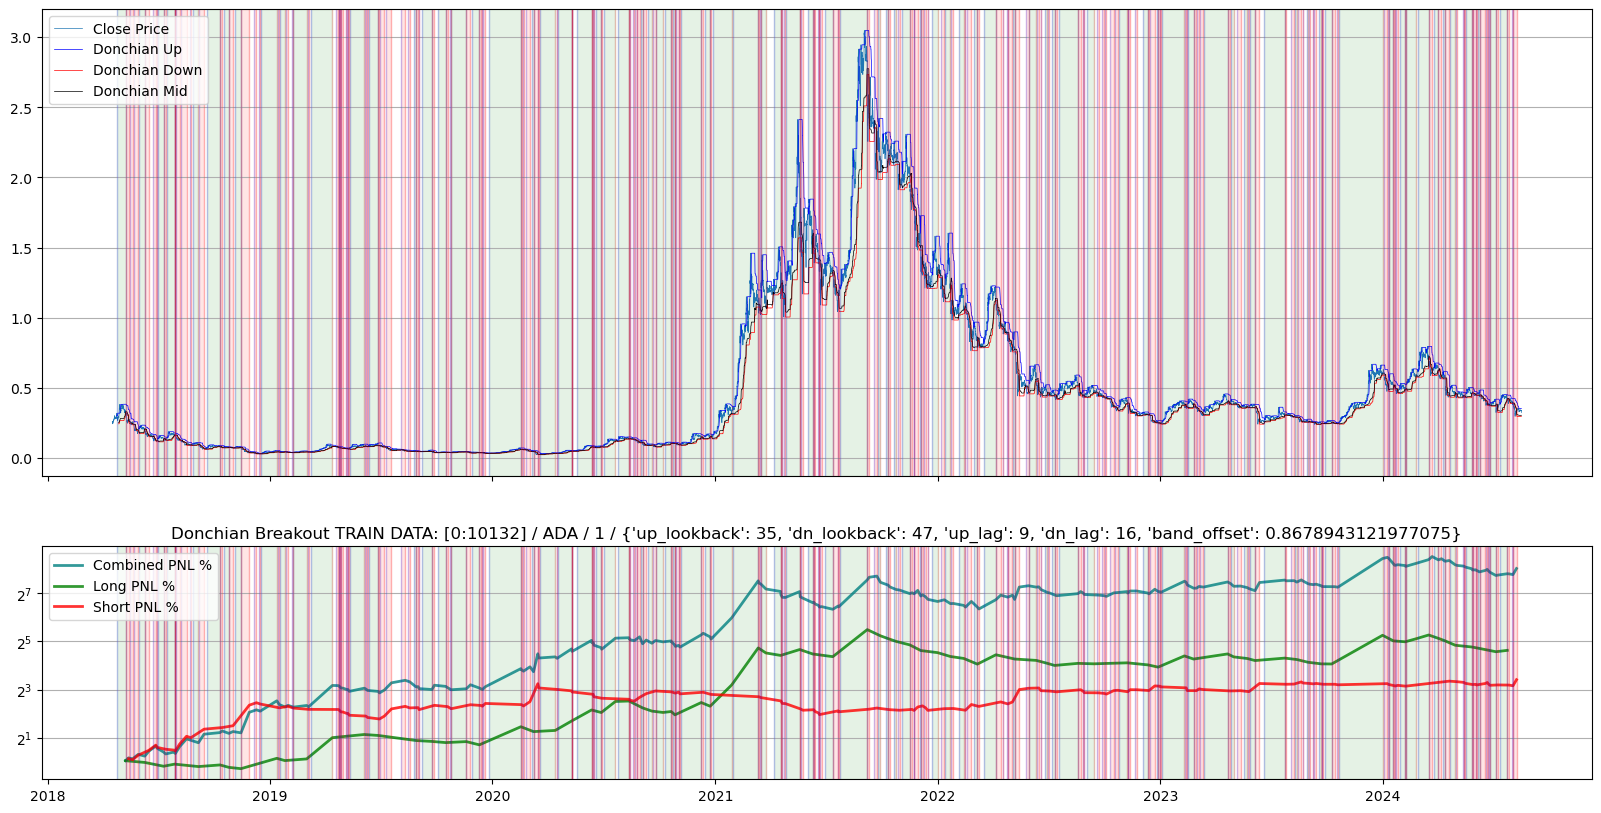

Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        453.8433 |        177.4640 |         99.6091
Max Drawdown              |        -54.2286 |        -47.3377 |        -22.4813
N Trades                  |         50.0000 |         19.0000 |         31.0000
Sharpe Ratio              |          0.1438 |          0.1475 |          0.1981
Sortino Ratio             |          0.8686 |          1.1512 |          0.7850
Avg Return                |          3.4827 |          5.5180 |          2.2547
Max Win                   |        322.4793 |        322.4793 |         43.5542
Max Loss                  |        -16.4423 |        -16.4423 |        -10.0997
Avg Win                   |         25.2943 |         53.9194 |         14.9998
Avg Loss                  |         -6.2271 |         -7.7923 |         -5.0568
Win Ratio                 |          0.

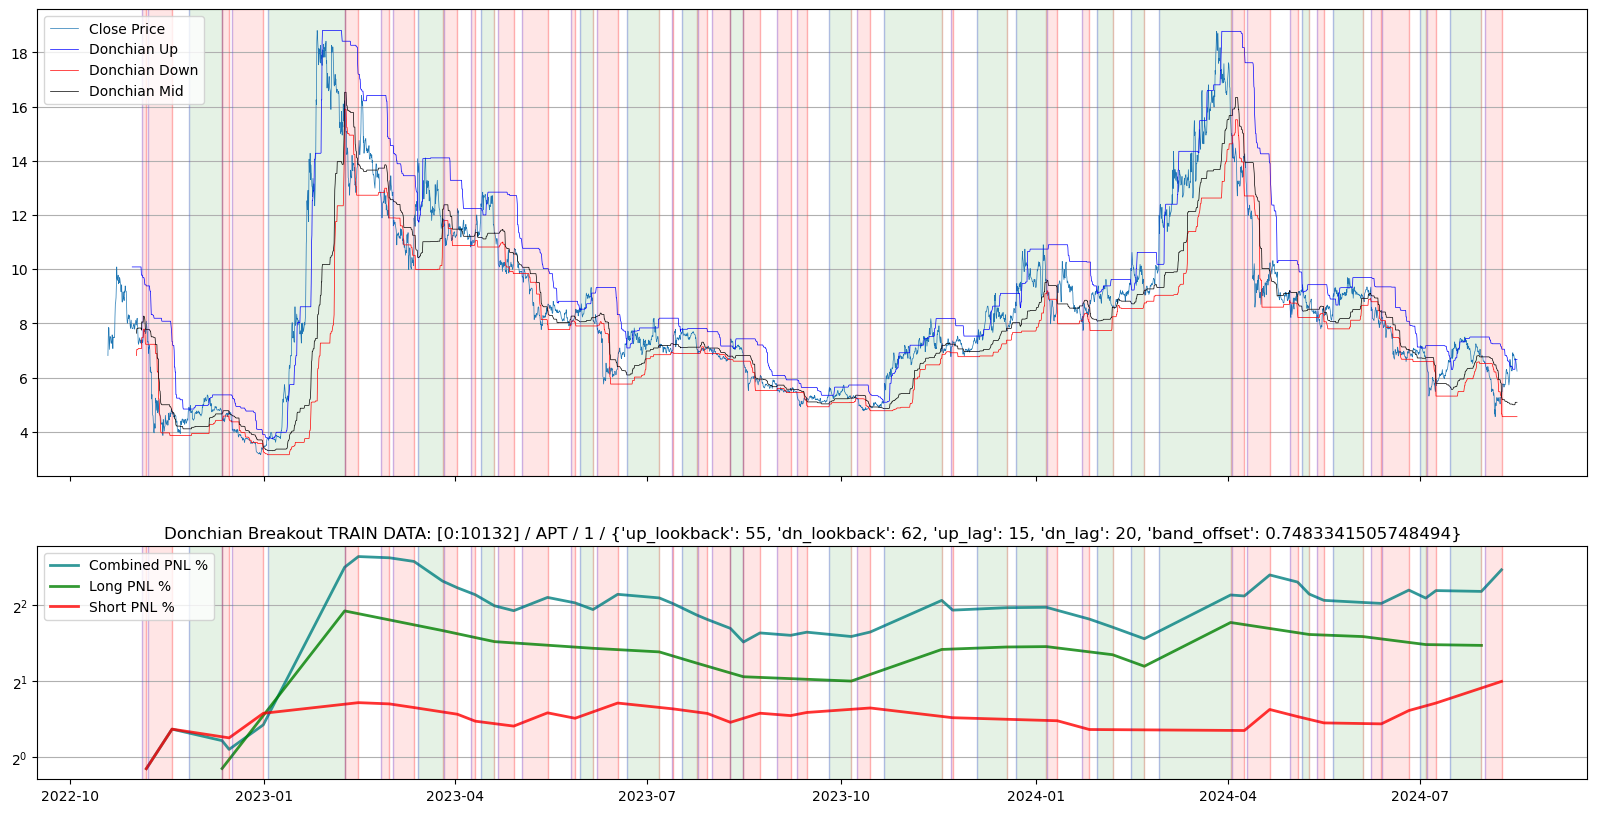

Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |      20759.5123 |       6231.1527 |        229.4742
Max Drawdown              |        -51.6060 |        -37.1651 |        -34.2478
N Trades                  |        103.0000 |         36.0000 |         67.0000
Sharpe Ratio              |          0.1976 |          0.2830 |          0.1447
Sortino Ratio             |          0.8925 |          1.7343 |          0.3926
Avg Return                |          5.3216 |         12.2125 |          1.7955
Max Win                   |        295.6639 |        295.6639 |         79.9862
Max Loss                  |        -19.9735 |        -19.9735 |        -19.5071
Avg Win                   |         23.0582 |         48.6512 |         11.6241
Avg Loss                  |         -7.5754 |        -10.3935 |         -5.9716
Win Ratio                 |          0.

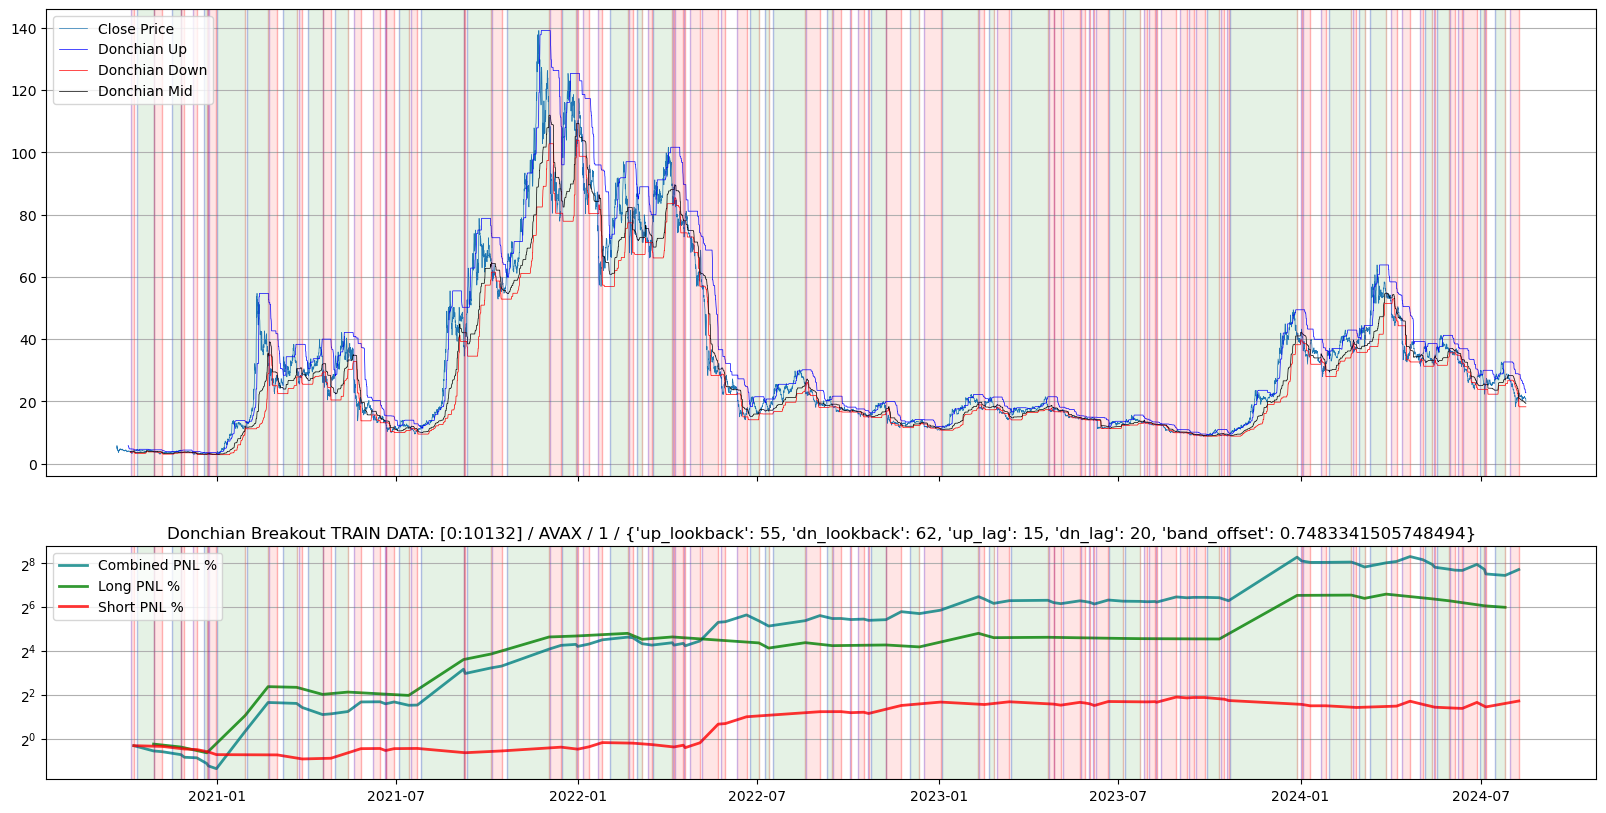

Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        902.1078 |        852.8054 |          5.1744
Max Drawdown              |        -61.3350 |        -76.2863 |        -70.0305
N Trades                  |        158.0000 |         24.0000 |        134.0000
Sharpe Ratio              |          0.0603 |          0.1593 |          0.0043
Sortino Ratio             |          0.2015 |          0.6958 |          0.0145
Avg Return                |          1.4694 |          9.8479 |          0.0377
Max Win                   |       1158.8294 |       1158.8294 |         47.0567
Max Loss                  |        -34.4760 |        -34.4760 |        -13.1882
Avg Win                   |         22.6727 |         74.1969 |         11.7983
Avg Loss                  |         -5.4809 |        -16.7004 |         -3.6723
Win Ratio                 |          0.

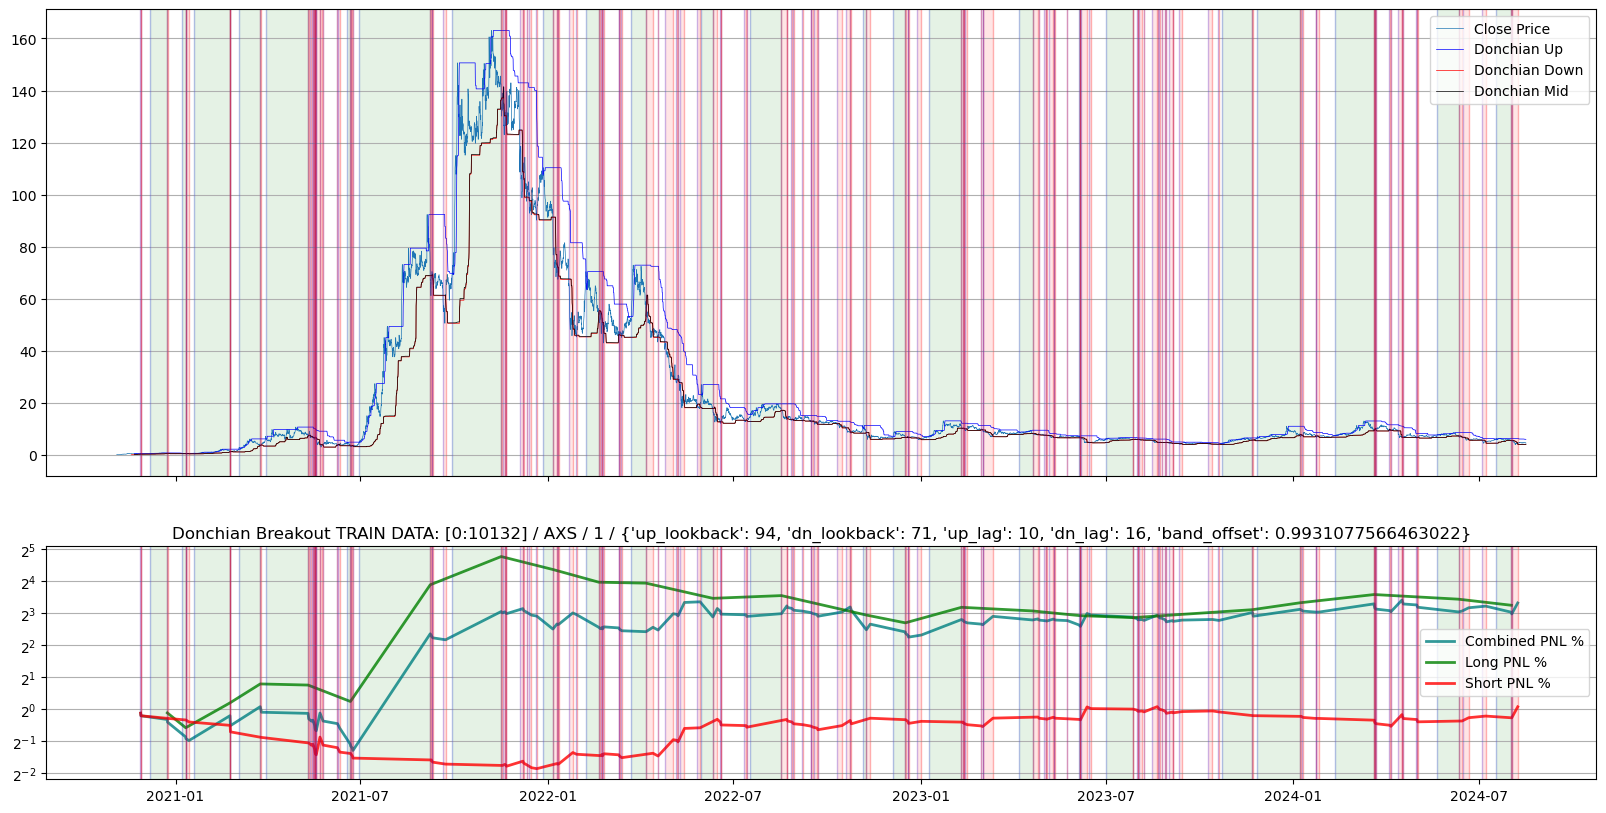

FileNotFoundError: File /media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance/BEAM_USDT-4h.json does not exist

In [284]:
for ix, asset, ipa, tfr in df[['asset','ipa','tfr']].to_records():
    data = load_candles(exchange,asset,quote,tfr)#['2021':]
    fig_tr,res_tr = print_performance(data,nhours,asset,reset_index=False,params=aparams[ipa],btkwargs={'short_long':[1,-1], 'xmult':1, 'slippage': 0.005, 'transaction_cost': 0.001, 'period_costs': 0.0003/6}, title=f'TRAIN DATA: [0:{data_train.shape[0]}]')

In [ ]:
[c for c in df.columns if c[0] not in ['long_metrics','short_metrics','overall_metrics'] or c[1] in ['tot_return','max_drawdown'] ]


## Randomize params and assets, test for robustness

In [ ]:
timeframe,quote,nhours ='1h', 'USDT', 4
# np.random.seed = 3
opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]


In [ ]:

rand_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
rand_backtests.sort_values('tot_return').tail()

In [ ]:
rand_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe()


In [ ]:
rand_backtests.hist(bins=50,figsize=(20,8))
plt.tight_layout()

## Simulate 100 randomized parameter set picks

In [ ]:
## Run a bunch of randomized simulations
timeframe,quote,nhours ='1h', 'USDT', 8
ran_sumul = []
for i in tqdm(range(10)):
    opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]
    ran_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
    ran_sumul.append(ran_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe().to_dict())
    
# np.histogram(ran_sumul)


In [ ]:
ran_sumul
# pd.DataFrame.from_records(ran_sumul)
# simul_rets = pd.Series(ran_sumul)
# simul_rets.describe(),simul_rets.hist(bins=50)

In [ ]:

opt_backtests = [print_performance(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':],nhours,params,backtest,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]

## Generate pinescript for a bunch of assets

In [ ]:
assets = ['ADA', 'ALGO', 'DOT', 'LINK', 'SOL']
exchange = 'BINANCE'
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#/ math.cos(number_of_trades)
nhours = 1
# data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [1]
asset_params = {}
for asset in assets:
    data = load_candles('binance',asset,'USDT','8h')#['2011':'2025']#.iloc[-10000:]
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    asset_params[f'{asset}USDT'] = study.best_trials[-1].params

In [ ]:
asset_params

In [ ]:
from jinja2 import Template
quote = 'USDT'
# Define the template (could also be loaded from a .jinja2 file)
template_str = """
//@version=5
indicator("Custom Donchian with Asset-Specific Parameters", overlay=true)

up_lag = 20
up_lookback = 20
dn_lag = 20
dn_lookback = 20
split_string = str.split(ticker.standard(),":")
string tkr = split_string.last()
// Determine parameters based on asset
{% for asset, params in asset_params.items() %}
if (tkr == "{{ asset }}{{ quote }}")
    up_lag := {{ params.up_lag }}
    dn_lag := {{ params.dn_lag }}
    up_lookback := {{ params.up_lookback }}
    dn_lookback := {{ params.dn_lookback }}
{% endfor %}

// Upper Donchian Band: Highest high over the up_lookback period, shifted by donch_up periods
upper_band = ta.highest(high, up_lookback)[up_lag]
// Lower Donchian Band: Lowest low over the dn_lookback period, shifted by donch_dn periods
lower_band = ta.lowest(low, dn_lookback)[dn_lag]
// Middle line between the upper and lower bands
middle_line = (upper_band + lower_band) / 2

// Plotting the upper and lower bands
plot(upper_band, title="Upper Donchian Band", color=color.green, linewidth=2)
plot(lower_band, title="Lower Donchian Band", color=color.red, linewidth=2)
plot(middle_line, title="Middle Line", color=color.gray, linewidth=2)

"""

template_str2 = """
bla
{% for asset in assets %}
 "{{ asset }}"
{% endfor %}
"""
# Create a template object
template = Template(template_str)

# Render the template with the asset_params dictionary
rendered_pine_script = template.render(asset_params=asset_params, quote=quote)

# Output the generated Pine Script
print(rendered_pine_script)



## Split data into training and testing set

In [ ]:
np.min([params[k] for k in params])

In [ ]:

data = load_candles('binance','BTC','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 8
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]

train_ratio = 0.3; 
cutoff = int(train_ratio * data.shape[0])
train_data, test_data = data.iloc[:cutoff,:], data.iloc[cutoff+1-np.max([params[k] for k in params]):,:]

study = optimize(train_data, nhours,backtest_fn=backtest, short_long=short_long)
params = study.best_params
params = {'tenkan_period': 19, 'kijun_period': 22, 'senkou_span_b_period': 22}
print(f'params = {params}')
print_performance(test_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print_performance(train_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print(f'params = {params}')

In [ ]:
train_data

## Backtest in a LOOP

In [ ]:
   
def backtest(data, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    if 1 in short_long:
        data.loc[data['bull'], 'position'] = 1        
        data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    if -1 in short_long:
        data.loc[(data['bear']), 'position'] = -1    
        data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    # data['position'] = xmult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) -1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) -1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / nhours)
    sharpe_ratio = annualized_return / annualized_volatility
    

## Forward Testing

In [ ]:
# data = load_futures_candles('bybit','ADA','USDT','1h')['2020':'2023']
data = load_candles('binance','BTC','USDT','1h')['2020':'2025']
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 8 ; ntrain = 3 ; ndays = 30
short_long = [1]
data = data.resample(f'{nhours}H').agg(ohlc_dict)#[:'2022']
n = data.shape[0]
w = (24 // nhours) * ndays
fwd_params = []
for i in tqdm(range(ntrain, (n // w)-1)):
    fwd_params.append(optimize(data.iloc[(i-ntrain)*w:(i)*w-1], nhours, short_long=short_long,xmult=1).best_params)
    

In [ ]:
df_params = pd.DataFrame(fwd_params)
df_params.describe()

In [ ]:


bt_arr = []; res_arr =[]
for i in tqdm(range(ntrain, (n // w)-1)):    
    # print(i)
    wdata = indicators(data.iloc[i*w:(i+1)*w],fwd_params[i-ntrain])
    results = backtest(wdata,nhours,short_long)
    decorate_trades(wdata)
    bt_arr.append(wdata)
    res_arr.append(results)

In [ ]:
data.shape[0], w, i, i*w, (i+1)*w

In [ ]:
df_res = pd.DataFrame(res_arr)
df_res#.describe()

In [ ]:
df_res.sharpe_ratio.mean(), (1+df_res.total_return).cumprod().values[-1], df_res.number_of_trades.sum()

In [ ]:
df_trd = pd.concat(bt_arr)
ax = df_trd['pct_strategy_returns'].add(1).cumprod().subtract(1).plot()
# df_trd['pct_cumulative_returns'].plot(ax=ax)

In [ ]:
df_trd

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [ ]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


In [ ]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

In [ ]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
